In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import psutil

from src.graph_utils.reading import read_graph6, read_metadata
from src.descriptors.edge_descriptors import edge_descriptors_dict
from src.descriptors.node_descriptors import node_descriptors_dict
from src.comparison import tests

from src.settings import Settings


In [3]:
for filename in os.listdir(Settings.raw_datasets_dir):
    if '.txt' in filename:
        old_filename = os.path.join('raw_datasets', filename)
        new_filename = re.sub(r'.txt', '', old_filename)
        print(old_filename, new_filename)

        os.rename(old_filename, new_filename)

In [4]:
psutil.cpu_count()

12

In [5]:
single_features = [(k, ) for k in edge_descriptors_dict.keys()]

node_features = [(f, ) for f in list(filter(lambda k: 'ldp' not in k, node_descriptors_dict.keys()))]
node_features.extend([tuple(filter(lambda k: 'ldp' in k and 'normalized' not in k, node_descriptors_dict.keys()))])
node_features.extend([tuple(filter(lambda k: 'ldp' in k and ('normalized' in k or 'degree' in k), node_descriptors_dict.keys()))])

single_features.extend(node_features)
single_features

[('jaccard_index',),
 ('jaccard_index_normalized',),
 ('adamic_adar',),
 ('katz_index',),
 ('neighborhood_distance',),
 ('neighborhood_measure',),
 ('preferential_attachment',),
 ('resource_allocation',),
 ('same_community',),
 ('total_nieghbors',),
 ('algebraic_distance',),
 ('ari',),
 ('lds',),
 ('scan',),
 ('cn_quadrangle',),
 ('cn_triangle',),
 ('lss',),
 ('simmelian_sparsifier_np',),
 ('edge_betweenness',),
 ('edge_betweenness_normalized',),
 ('spanning_edge',),
 ('eigenvector_centrality',),
 ('closeness',),
 ('closeness_normalized',),
 ('degree_centrality',),
 ('degree_centrality_normalized',),
 ('katz_centrality',),
 ('lcc',),
 ('ldp_degree', 'ldp_min', 'ldp_max', 'ldp_mean', 'ldp_std'),
 ('ldp_degree',
  'ldp_min_normalized',
  'ldp_max_normalized',
  'ldp_mean_normalized',
  'ldp_std_normalized')]

In [6]:
import os
from src.graph_utils.dataset import Dataset

arguments_list = []
for dataset_name in ['graph5']:
# for dataset_name in  map(lambda x: '.'.join(x.split('.')[:-1]), filter(lambda x: '.g6' in x, os.listdir(READ_DIR))):
    # for features in [("moltop",), ("moltop","ltp"), ("moltop", "ldp"), ("moltop", "ltp", "ldp")]:

    dataset = Dataset(name=dataset_name)
    for features in single_features:
    
        features = np.array(features)
        arguments_list.append(dict(dataset=dataset,
                                    features=features,))

In [7]:
tests(arguments_list)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [8]:
metadata = read_metadata()

In [11]:
from collections import Counter

def count_elements(row_string):
    c = Counter(row_string)
    return c[','] + 1 if ',' in c else 0
test_data = pd.read_parquet(Settings.processed_datasets_dir / 'table.parquet')
test_data['count'] = test_data['result'].apply(count_elements)

test_data['percentage'] = test_data.apply(lambda x: x['count'] / metadata[x['dataset']]['graph_count'], axis=1)

In [12]:
test_data = test_data.reset_index(drop=True)
test_data

,features,dataset_name,result,dataset,count,percentage
0,[jaccard_index],None,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",graph5,0,0.0
1,[jaccard_index_normalized],None,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",graph5,0,0.0
2,[adamic_adar],None,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",graph5,0,0.0
3,[katz_index],None,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",graph5,0,0.0
4,[neighborhood_distance],None,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",graph5,0,0.0
5,[neighborhood_measure],None,"[4, 13]",graph5,0,0.0
6,[preferential_attachment],None,"[4, 13]",graph5,0,0.0
7,[resource_allocation],None,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",graph5,0,0.0
8,[same_community],None,"[2, 5, 3, 6, 7, 11, 12, 15, 26, 9, 13, 16, 17,...",graph5,0,0.0
9,[total_nieghbors],None,"[14, 26]",graph5,0,0.0


In [14]:

test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'dataset', 'count', 'percentage'], dtype='object')

c:\Users\Przemek\Documents\Studia\10_semestr\magisterka\Analysis-of-graph-topological-descriptors-for-the-graph-isomorphism-problem\.venv\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)


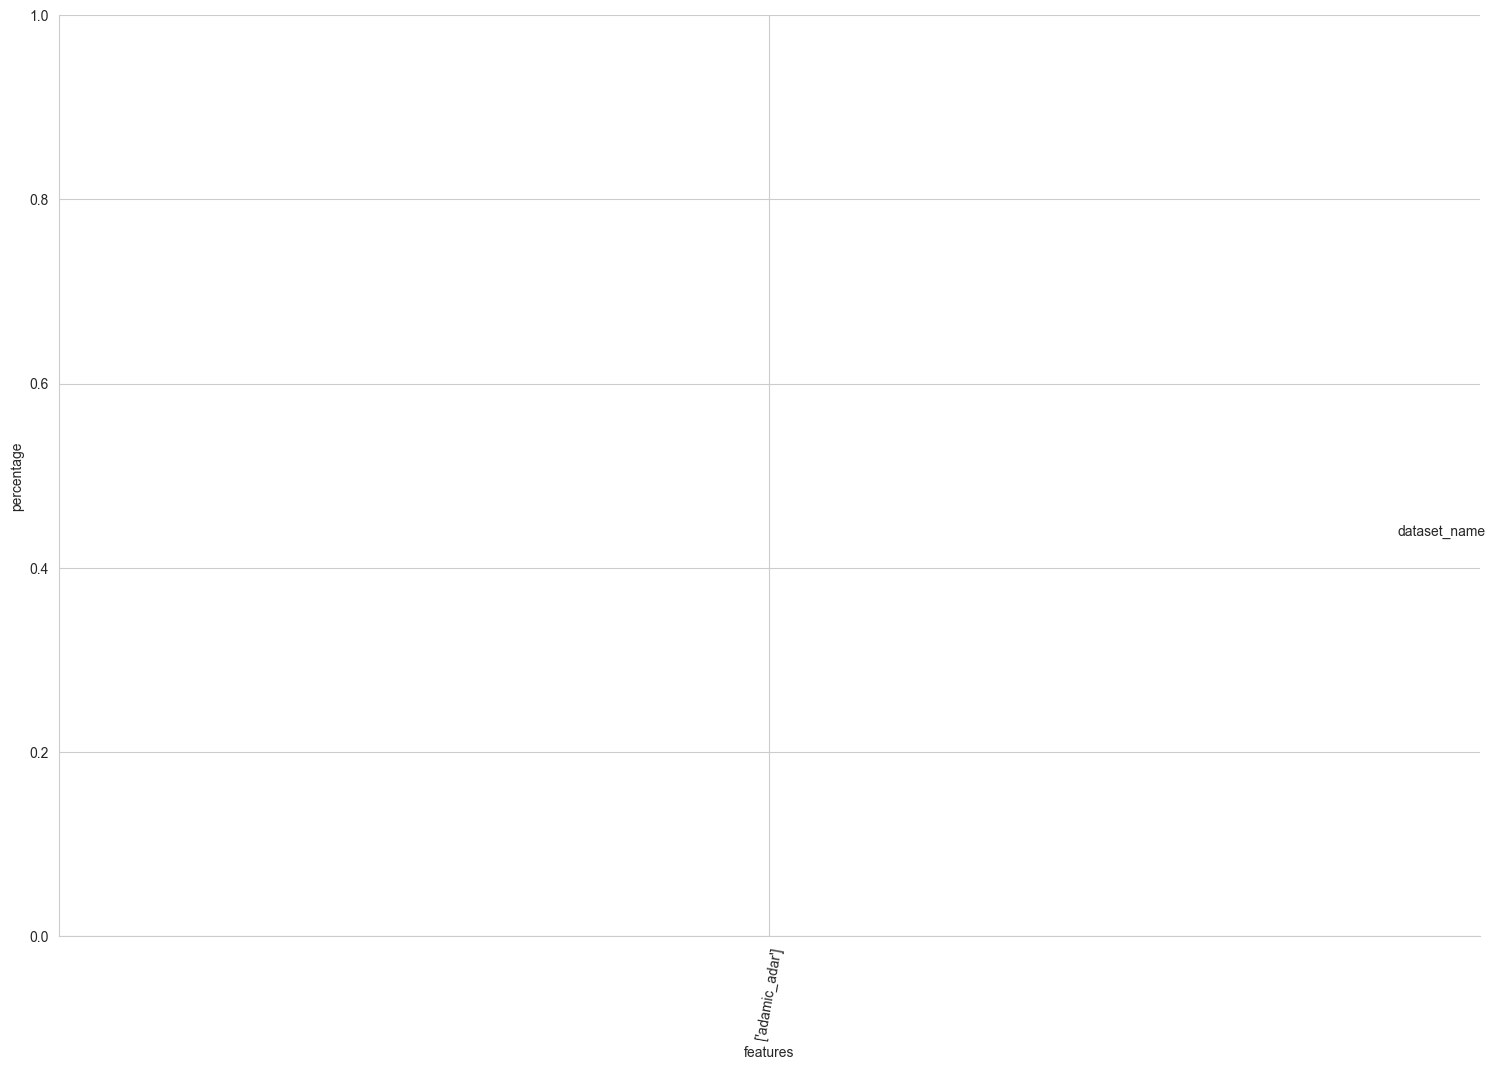

In [ ]:
dataset_search = 'graph'

g = sns.pairplot(test_data[test_data['dataset'].map(lambda x: dataset_search in x)], 
             y_vars=['percentage'],
             x_vars=['features'],
             hue='dataset',
             palette='Spectral'
             )
fig = plt.gcf()
fig.set_size_inches(15,10)
plt.tight_layout()

for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(80)



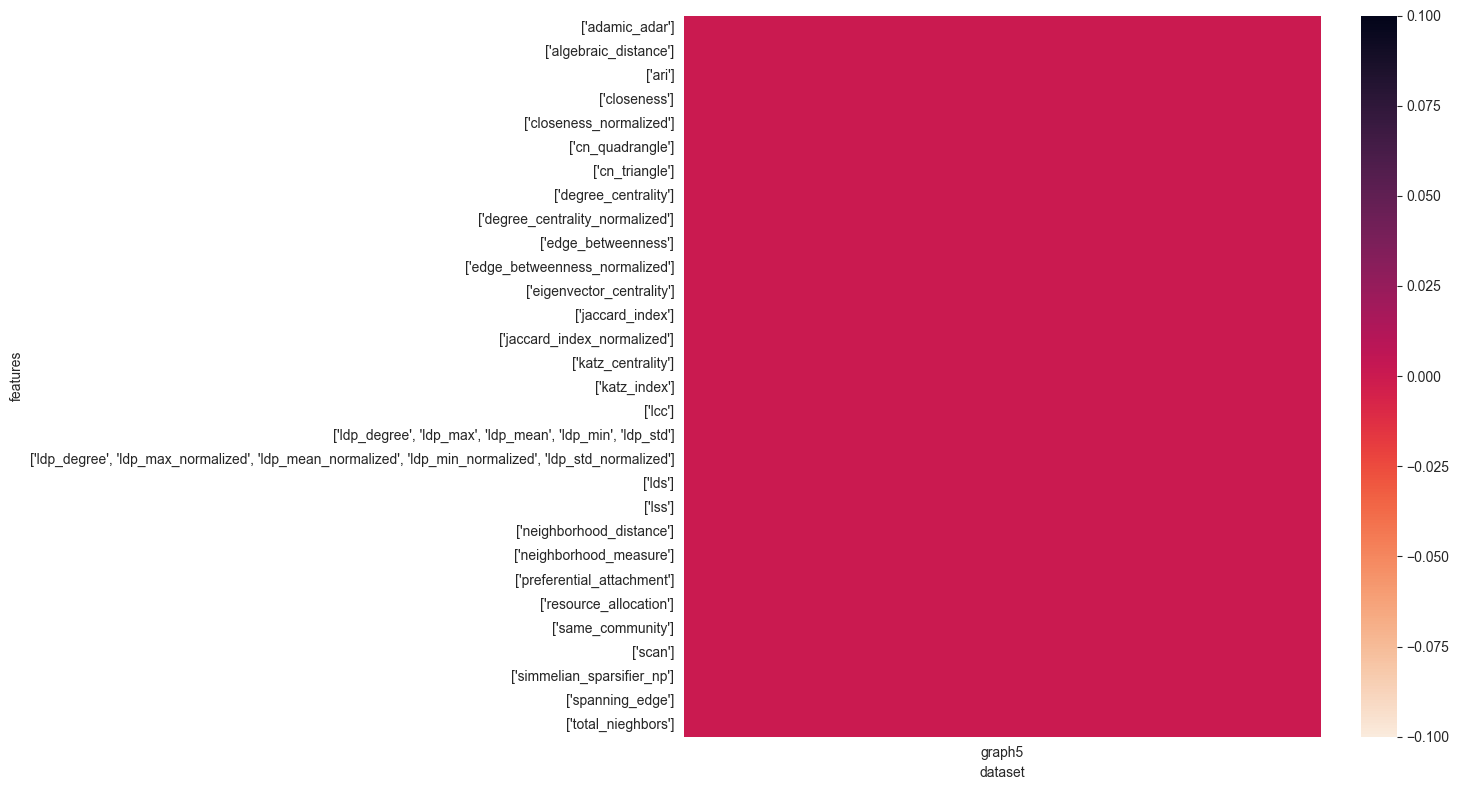

In [18]:
data2d = test_data.pivot(index="features", columns="dataset", values="percentage")

g = sns.heatmap(data=data2d, cmap='rocket_r')
fig = plt.gcf()
fig.set_size_inches(15,8)
plt.tight_layout()

g.set_yticks(np.arange(data2d.shape[0]) + 0.5)

_ = g.set_yticklabels(data2d.index)

g.set_xticks(np.arange(data2d.shape[1]) + 0.5)

_ = g.set_xticklabels(data2d.columns)
